4.6 Project Python Predictive Analytics - 08/22/2026 - Lasgat0980

In [1]:
#Import Libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
from IPython.display import display, Markdown

#Variables
student_id = "Lasgat0980"
todays_date = datetime.now().strftime("%Y-%m-%d")

#Load the dataset
file_path = r"C:\Users\ldick\Downloads\StudentsPerformanceWk4.xlsx"
df = pd.read_excel(file_path)

#Display the dataset
display(df.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,free/reduced,completed,100,100,93
1,female,group E,some college,standard,none,100,92,97
2,female,group E,bachelor's degree,standard,none,100,100,100
3,male,group A,some college,standard,completed,100,96,86
4,male,group D,some college,standard,completed,100,97,99


In [2]:
#Transform categorical columns using one-hot encoding

df_new = pd.get_dummies(df, columns=['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'])

#Display the encoded dataset

display(df_new.head())

,math score,reading score,writing score,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,100,100,93,False,True,False,False,False,False,True,True,False,False,False,False,False,True,False,True,False
1,100,92,97,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,True
2,100,100,100,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True
3,100,96,86,False,True,True,False,False,False,False,False,False,False,False,True,False,False,True,True,False
4,100,97,99,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False


In [3]:
#Step 4: Define Features and Target for Regression

#Define the features (X) and the target (y) variables for regression
X = df_new.drop(['math score'], axis=1)
y = df_new['math score']

#Split the dataset into 80% training and 20% testing for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Show the training and test data sets
display(Markdown(f"### {student_id} - {todays_date}"))
display(Markdown("#### Features"))
display(X.head())
display(Markdown("#### Target"))
display(y.head())

### Lasgat0980 - 2026-08-25

#### Features

,reading score,writing score,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,100,93,False,True,False,False,False,False,True,True,False,False,False,False,False,True,False,True,False
1,92,97,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,True
2,100,100,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True
3,96,86,False,True,True,False,False,False,False,False,False,False,False,True,False,False,True,True,False
4,97,99,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False


#### Target

0    100
1    100
2    100
3    100
4    100
Name: math score, dtype: int64

In [4]:
#Step 5: Train the Linear Regression Model

#Create the Linear Regression model
model = LinearRegression()

#Train the model using the training data
model.fit(X_train, y_train)

#Display Header Text
display(Markdown(f"### {student_id} - {todays_date}"))
display(Markdown("#### Linear Regression Model Trained"))

### Lasgat0980 - 2026-08-25

#### Linear Regression Model Trained

In [5]:


#Make predictions on the test set
y_pred_test = model.predict(X_test)

#Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred_test)

#Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred_test)

#Calculate R-squared
r2 = r2_score(y_test, y_pred_test)

#Display model performance
display(Markdown(f"### {student_id} - {todays_date}"))

display(Markdown(f"Mean Absolute Error (MAE): {mae:.2f}"))
display(Markdown(f"Mean Squared Error (MSE): {mse:.2f}"))
display(Markdown(f"R-squared (R2): {r2:.2f}"))

### Lasgat0980 - 2026-08-25

Mean Absolute Error (MAE): 4.38

Mean Squared Error (MSE): 31.22

R-squared (R2): 0.86

In [6]:
#Step 7: Examine Linear Regression Coefficients

#Create a DataFrame of features and coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

#Display coefficients
display(Markdown(f"### {student_id} - {todays_date}"))
display(Markdown("#### Linear Regression Coefficients"))
display(coefficients)

### Lasgat0980 - 2026-08-25

#### Linear Regression Coefficients

,Feature,Coefficient
0,reading score,0.296309
1,writing score,0.664608
2,gender_female,-6.628636
3,gender_male,6.628636
4,race/ethnicity_group A,-1.326257
5,race/ethnicity_group B,-0.290050
6,race/ethnicity_group C,-1.096240
7,race/ethnicity_group D,-1.009359
8,race/ethnicity_group E,3.721907
9,parental level of education_associate's degree,0.402615


Lasgat0980 - 08/25/2026

| Actionable Feature | Description (Lasgat0980 - 08/25/2026) |
|------------------------------------------------------------|
| Reading Score      | Reading scores can be influenced through tutoring, reading intervention programs, additional instruction, and academic support. Improving reading performance may also have a positive effect on predicted math scores. 
| Test Preparation   | Schools can increase access to test preparation through tutoring sessions, workshops, study programs, and after-school support. This makes test preparation a feature that can be directly influenced through school programs. 
| Writing Score      | Writing performance can be improved through writing labs, tutoring, additional classroom instruction, and individualized academic support. 
| Lunch              | Schools can influence access to meals through nutrition programs and additional food assistance. Although schools cannot directly change a family's income level, they can provide programs that improve access to nutritious meals and reduce food insecurity. 

In [8]:
#Simulate Interventions


#Calculate the median math score
median_math_score = df_new['math score'].median()

#Select students with math scores below the median
subset = df_new[df_new['math score'] < median_math_score].copy()

#Remove math score to create the features for prediction
X_subset = subset.drop(['math score'], axis=1)

#Predict math scores before the intervention
predicted_before = model.predict(X_subset)

#Create a copy for the simulated intervention
X_intervention = X_subset.copy()

#Increase reading scores by 5%
X_intervention['reading score'] = X_intervention['reading score'] * 1.05

#Find students receiving free/reduced lunch
free_reduced_students = X_intervention[X_intervention['lunch_free/reduced'] == True]

#Select 5% of the free/reduced lunch students
students_to_change = free_reduced_students.sample(frac=0.05, random_state=42).index

#Change selected students from free/reduced lunch to standard lunch
X_intervention.loc[students_to_change, 'lunch_free/reduced'] = False
X_intervention.loc[students_to_change, 'lunch_standard'] = True

#Predict math scores after the interventions
predicted_after = model.predict(X_intervention)

#Calculate the impact on predicted math scores
impact = predicted_after - predicted_before

#Display results
display(Markdown(f"### {student_id} - {todays_date}"))
display(Markdown("#### Simulated Intervention Results"))

print("Average Predicted Math Score Before Intervention:", predicted_before.mean())
print("Average Predicted Math Score After Intervention:", predicted_after.mean())
print("Average Change in Predicted Math Score:", impact.mean())

### Lasgat0980 - 2026-08-25

#### Simulated Intervention Results

Average Predicted Math Score Before Intervention: 55.083477463420074
Average Predicted Math Score After Intervention: 56.04110339785924
Average Change in Predicted Math Score: 0.9576259344391639


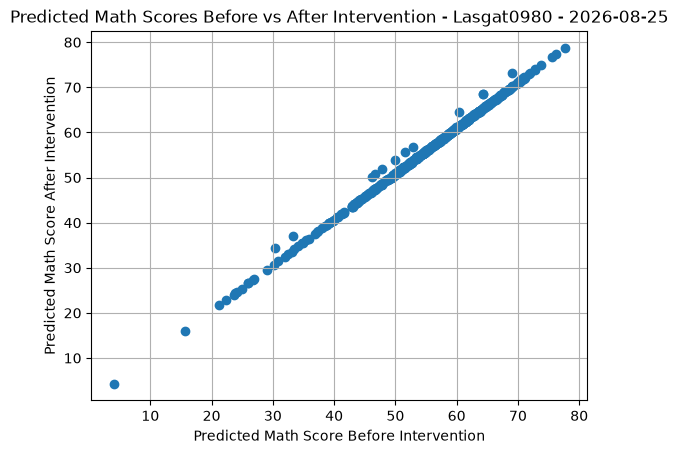

In [11]:
#Step 4: Scatter Plot of Predicted Math Scores Before and After Intervention

import matplotlib.pyplot as plt
#Create scatter plot
plt.scatter(predicted_before, predicted_after)

#Add labels and title
plt.xlabel("Predicted Math Score Before Intervention")
plt.ylabel("Predicted Math Score After Intervention")
plt.title(f"Predicted Math Scores Before vs After Intervention - {student_id} - {todays_date}")

#Add grid
plt.grid(True)

#Display plot
plt.show()